### **Random Forest Classification Implementation**

Data is collected from :https://www.kaggle.com/datasets/susant4learning/Holiday-package-purchase-prediction

In [2]:
#importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import warnings 

warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df=pd.read_csv("Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## **Data cleaning**

Handling missing values
1. Handling missing values
2. Handling duplicates
3. check data type
4. understand the dataset

In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
### check all categories

df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [8]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
#check missing values
##these are features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),'%missing values')

Age 4.62357 %missing values
TypeofContact 0.51146 %missing values
DurationOfPitch 5.13502 %missing values
NumberOfFollowups 0.92062 %missing values
PreferredPropertyStar 0.53191 %missing values
NumberOfTrips 2.86416 %missing values
NumberOfChildrenVisiting 1.35025 %missing values
MonthlyIncome 4.76678 %missing values


In [11]:
#statistics on numerical columns(null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


### imputing the missing values

1. imputing the age column with median value 
2. impute mode for type of contract
3. impute median for duration of pitch
4. impute mode for NumberofFollowup as it is discrete feature
5. impute mode for preffered property star
6. impute meadian for NumberofTrips
7. impute mode for number of children visiting 
8. impute median for monthly income

In [12]:
#imputing the missing values 
df.Age.fillna(df.Age.median(),inplace=True)

#type of contact
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)

#DurationofPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)

#PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)

#NumberofchildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)

#Monthly Income
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)


In [13]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [14]:
df.drop('CustomerID',inplace=True,axis=1)

###  Feature engineering


In [15]:
#create new columns for features
df['TotalVisiting'] = df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],axis=1,inplace=True)

In [16]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched',
       'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome',
       'TotalVisiting'],
      dtype='object')

In [17]:
#get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype !='O']
print('Num of Numerical Features :',len(num_features))

Num of Numerical Features : 12


In [18]:
#categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features: ',len(cat_features))

Num of Categorical Features:  6


In [19]:
#discrete features
discrete_features = [feature for feature in num_features if len (df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 9


In [20]:
#continious Feature
continuous_feature=[feature for feature in num_features if len(df[feature].unique())>25]
print('Num of continuous feature :',len(continuous_feature))


Num of continuous feature : 3


In [64]:
#independent and dependent variable 


X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [65]:
type(X)

pandas.core.frame.DataFrame

In [66]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [67]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.27,random_state=46)


In [68]:
type(X_train)

pandas.core.frame.DataFrame

In [69]:
X_train.shape,y_train.shape

((1319, 17), (1319,))

In [70]:
type(X_train)

pandas.core.frame.DataFrame

In [71]:
#create column transformer with 3 types of transformer

cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first',
                                handle_unknown='ignore')#ignored freelancer category

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer,cat_features),
        ('StandardScaler', numeric_transformer,num_features)
    ]
)

In [72]:
type(X_train)

pandas.core.frame.DataFrame

In [73]:
X_train = preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier #initialised other model(simillarlt u can add models)
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score, \
                            f1_score,roc_auc_score,roc_curve,ConfusionMatrixDisplay

In [ ]:
models={
    'Decision Tree' :DecisionTreeClassifier(), #adding one more model(added model have to be initialized)
    'Random Forest':RandomForestClassifier()
}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)#train models

    #make predicitons

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #training set performance
    model_train_accuracy = accuracy_score(y_train,y_train_pred)#
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)#
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score= roc_auc_score(y_train,y_train_pred)

    #test set performance
    model_test_accuracy = accuracy_score(y_test,y_test_pred)#
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)#
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score= roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('model performance for training set')
    print('- Accuracy: {:4f}'.format(model_train_accuracy))
    print('- F1 Score: {:4f}'.format(model_train_f1))
    print('- precision: {:4f}'.format(model_train_precision))
    print('- Recall: {:4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:4f}'.format(model_train_rocauc_score))

    print('---------------------------------------------')

    print('Model performance for test set')
    print('- Accuracy: {:4f}'.format(model_test_accuracy))
    print('- F! Score: {:4f}'.format(model_test_f1))
    print('- precision: {:4f}'.format(model_test_precision))
    print('- Recall: {:4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')


Decision Tree
model performance for training set
- Accuracy: 1.000000
- F1 Score: 1.000000
- precision: 1.000000
- Recall: 1.000000
- Roc Auc Score: 1.000000
---------------------------------------------
Model performance for test set
- Accuracy: 0.829084
- F! Score: 0.825208
- precision: 0.564437
- Recall: 0.502177
- Roc Auc Score: 0.704734


Random Forest
model performance for training set
- Accuracy: 1.000000
- F1 Score: 1.000000
- precision: 1.000000
- Recall: 1.000000
- Roc Auc Score: 1.000000
---------------------------------------------
Model performance for test set
- Accuracy: 0.858224
- F! Score: 0.832533
- precision: 0.832727
- Recall: 0.332366
- Roc Auc Score: 0.658197




In [82]:
#Hyper Parameter tuning
rf_params={
    "max_depth":[5,8,15,None,10],
    "max_features":[5,7,'auto',8],
    "min_samples_split":[2,8,15,20],
    "n_estimators":[100,200,500,1000]

}

In [83]:
#Models list for Hyperparameter Tunning

randomcv_models = [
    ("RF",RandomForestClassifier(),rf_params)
]

In [84]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]})]

In [85]:
from sklearn.model_selection import RandomizedSearchCV

model_param ={}

for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,param_distributions=params,
                                n_iter=100,
                                cv=2,verbose=2,n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f'------------------Best Params for {model_name}----------------')
    print(model_param[model_name])

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END max_depth=5, max_features=auto, min_samples_split=8, n_estimators=500; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_split=8, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=8, min_samples_split=20, n_estimators=200; total time=   1.0s
[CV] END max_depth=5, max_features=7, min_samples_split=8, n_estimators=200; total time=   1.9s
[CV] END max_depth=5, max_features=7, min_samples_split=8, n_estimators=200; total time=   0.8s
[CV] END max_depth=None, max_features=8, min_samples_split=20, n_estimators=200; total time=   0.8s
[CV] END max_depth=5, max_features=auto, min_samples_split=15, n_estimators=1000; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_sa

In [86]:
models={
    #again train the model with the best params
    'Random Forest':RandomForestClassifier(n_estimators=200,min_samples_split=2,max_features=5,max_depth=15)
}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)#train models

    #make predicitons

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #training set performance
    model_train_accuracy = accuracy_score(y_train,y_train_pred)#
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)#
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score= roc_auc_score(y_train,y_train_pred)

    #test set performance
    model_test_accuracy = accuracy_score(y_test,y_test_pred)#
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)#
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score= roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('model performance for training set')
    print('- Accuracy: {:4f}'.format(model_train_accuracy))
    print('- F1 Score: {:4f}'.format(model_train_f1))
    print('- precision: {:4f}'.format(model_train_precision))
    print('- Recall: {:4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:4f}'.format(model_train_rocauc_score))

    print('---------------------------------------------')

    print('Model performance for test set')
    print('- Accuracy: {:4f}'.format(model_test_accuracy))
    print('- F! Score: {:4f}'.format(model_test_f1))
    print('- precision: {:4f}'.format(model_test_precision))
    print('- Recall: {:4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')


Random Forest
model performance for training set
- Accuracy: 1.000000
- F1 Score: 1.000000
- precision: 1.000000
- Recall: 1.000000
- Roc Auc Score: 1.000000
---------------------------------------------
Model performance for test set
- Accuracy: 0.858784
- F! Score: 0.834853
- precision: 0.815700
- Recall: 0.346880
- Roc Auc Score: 0.664065




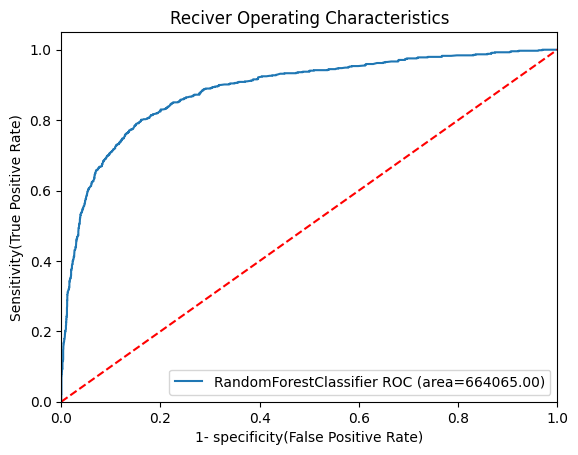

In [ ]:
#plot ROC Auc Score

from sklearn.metrics import roc_auc_score,roc_curve
plt.Figure()

#add the models to the list that you want to view on the ROC plot

auc_models = [
    {
        'label':"RandomForestClassifier",
        'model': RandomForestClassifier(n_estimators=200,min_samples_split=2,max_features=5,
                                       max_depth=15),
        'auc':664065
    },
]
#create loop through all model 

for algo in auc_models:
    model = algo['model']#select the model
    model.fit(X_train,y_train) #train the models

#compute false positive rate and true positive rate
    fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,1])

#calculate area under the curve to display on the plot
    plt.plot(fpr,tpr,label='%s ROC (area=%0.2f)'%(algo['label'],algo['auc']))#instead of algo[auc],use auc_score for dynamic

#custom setting for the plot

plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1- specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Reciver Operating Characteristics')
plt.legend(loc='lower right')
plt.savefig("auc.png")
plt.show()